# 08 - Quality Assurance dashboard

This notebook computes the customer-complaint, supplier-quality, and
nonconformance/CAPA indicators -- the part of the project that looks
beyond the shop floor: how the customer experiences the product, and
how the incoming raw material looks.


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import etl_lib as etl

PROCESSED = "../../datasets/processed"
REPORTS = "../../reports"
os.makedirs(REPORTS, exist_ok=True)

dim_customer = pd.read_csv(f"{PROCESSED}/dim_customer.csv", encoding="utf-8-sig")
dim_supplier = pd.read_csv(f"{PROCESSED}/dim_supplier.csv", encoding="utf-8-sig")

sales = pd.read_csv(f"{PROCESSED}/fact_sales_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
complaints = pd.read_csv(f"{PROCESSED}/fact_customer_complaints_processed.csv", encoding="utf-8-sig", parse_dates=["Date", "ResolutionDate"])
raw_material_inspection = pd.read_csv(f"{PROCESSED}/fact_raw_material_inspection_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
raw_material_disposition = pd.read_csv(f"{PROCESSED}/fact_raw_material_lot_disposition_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
supplier_complaints = pd.read_csv(f"{PROCESSED}/fact_supplier_complaints_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
nonconformance = pd.read_csv(f"{PROCESSED}/fact_nonconformance_processed.csv", encoding="utf-8-sig", parse_dates=["Date"])
capa = pd.read_csv(f"{PROCESSED}/fact_capa_processed.csv", encoding="utf-8-sig", parse_dates=["OpenDate", "DueDate", "CloseDate"])

complaints = complaints.merge(dim_customer[["CustomerId", "CustomerName", "Segment", "City"]], on="CustomerId", how="left")
print("Data loaded.")


Data loaded.


# Part 1 - Customer complaints

## Complaint count (total and by severity)

Total complaints: 397
Severity
Critical    154
Major       128
Minor       115
Name: count, dtype: int64


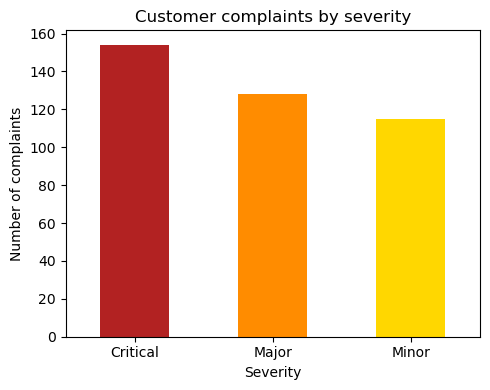

In [17]:
print(f"Total complaints: {len(complaints):,}")
print(complaints["Severity"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
complaints["Severity"].value_counts().reindex(["Critical", "Major", "Minor"]).plot(
    kind="bar", color=["firebrick", "darkorange", "gold"], ax=ax
)
ax.set_ylabel("Number of complaints")
ax.set_title("Customer complaints by severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{REPORTS}/21_complaints_by_severity.png", dpi=150)
plt.show()


## Complaints by customer

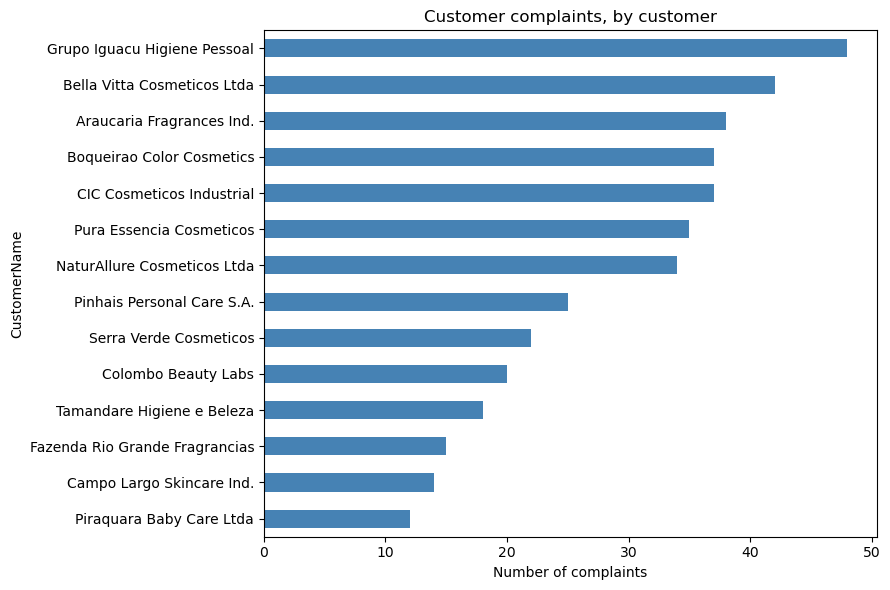

In [18]:
complaints_by_customer = complaints.groupby("CustomerName").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
complaints_by_customer.plot(kind="barh", color="steelblue", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Number of complaints")
ax.set_title("Customer complaints, by customer")
plt.tight_layout()
plt.savefig(f"{REPORTS}/22_complaints_by_customer.png", dpi=150)
plt.show()


## Complaints by product / by family

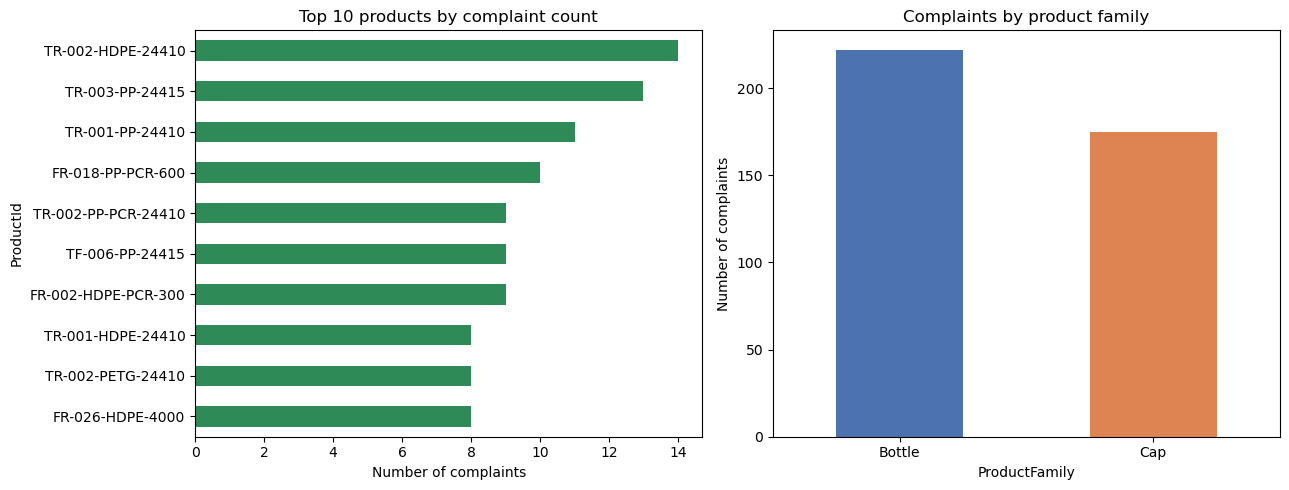

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

complaints.groupby("ProductId").size().sort_values(ascending=False).head(10).plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 products by complaint count")
axes[0].set_xlabel("Number of complaints")

complaints.groupby("ProductFamily").size().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Complaints by product family")
axes[1].set_ylabel("Number of complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{REPORTS}/23_complaints_by_product_and_family.png", dpi=150)
plt.show()


## Complaints by defect type

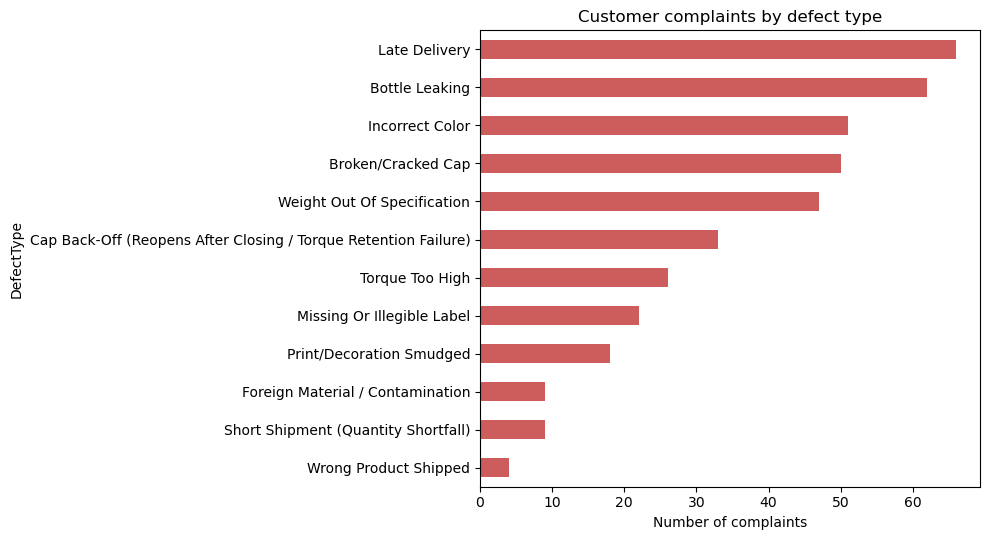

In [20]:
complaints_by_defect = complaints.groupby("DefectType").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
complaints_by_defect.plot(kind="barh", color="indianred", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Number of complaints")
ax.set_title("Customer complaints by defect type")
plt.tight_layout()
plt.savefig(f"{REPORTS}/24_complaints_by_defect_type.png", dpi=150)
plt.show()


## Monthly trend

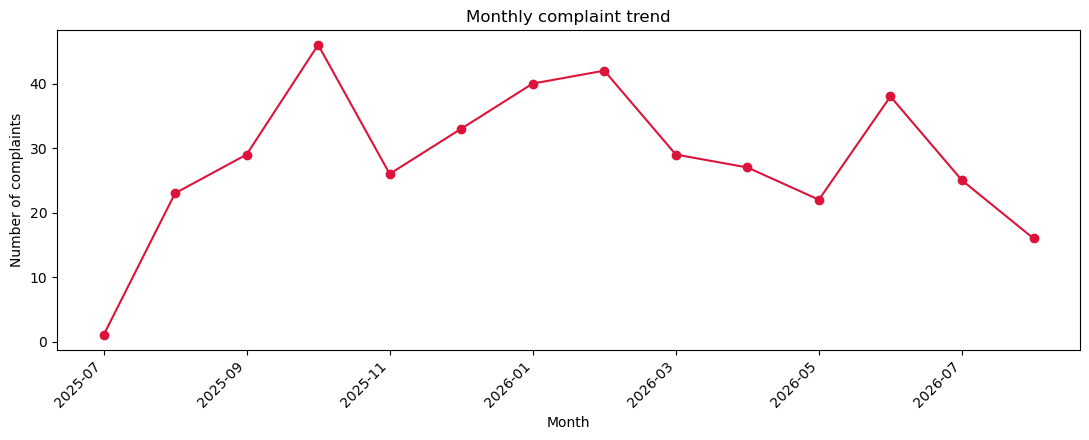

In [21]:
complaints_by_month = complaints.groupby("Month").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
complaints_by_month.plot(kind="line", marker="o", color="crimson", ax=ax)
ax.set_ylabel("Number of complaints")
ax.set_xlabel("Month")
ax.set_title("Monthly complaint trend")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{REPORTS}/25_complaints_monthly_trend.png", dpi=150)
plt.show()


## Complaints per million units shipped (CPMU)

The normalized version of "how many complaints" -- comparing raw
counts across customers or products with very different volumes is
misleading; CPMU puts everyone on the same scale.


Plant-wide CPMU: 6.6 complaints per million units shipped


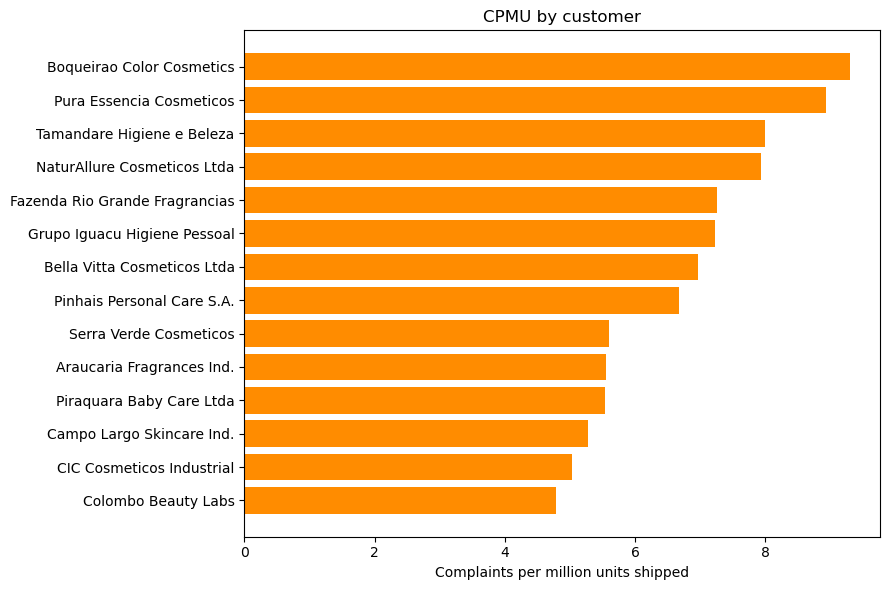

In [22]:
overall_cpmu = etl.compute_complaints_per_million_shipped(complaints, sales)
print(f"Plant-wide CPMU: {overall_cpmu.iloc[0]:.1f} complaints per million units shipped")

cpmu_by_customer = etl.compute_complaints_per_million_shipped(
    complaints, sales, group_columns=["CustomerId"]
).sort_values(ascending=False)
cpmu_by_customer = cpmu_by_customer.to_frame().join(dim_customer.set_index("CustomerId")[["CustomerName"]])

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(cpmu_by_customer["CustomerName"], cpmu_by_customer["ComplaintsPerMillionShipped"], color="darkorange")
ax.invert_yaxis()
ax.set_xlabel("Complaints per million units shipped")
ax.set_title("CPMU by customer")
plt.tight_layout()
plt.savefig(f"{REPORTS}/26_cpmu_by_customer.png", dpi=150)
plt.show()


# Part 2 - Supplier quality

## Complaints filed against suppliers

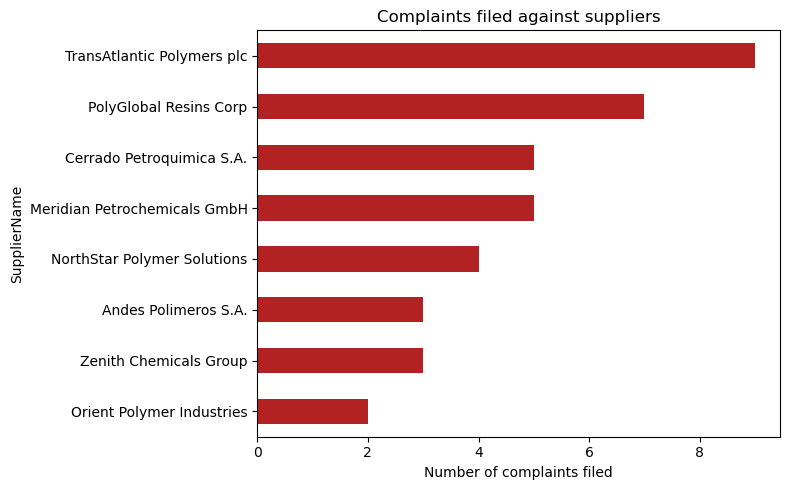

By issue type:
IssueType
Off-Spec Test Result                 15
Short Shipment                        7
Documentation Error / Missing Coa     7
Packaging Damaged In Transit          4
Late Delivery Of Po                   2
Wrong Material Supplied               2
Contamination                         1
Name: count, dtype: int64


In [23]:
complaints_by_supplier = (
    supplier_complaints.merge(dim_supplier[["SupplierId", "SupplierName"]], on="SupplierId")
    .groupby("SupplierName").size().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
complaints_by_supplier.plot(kind="barh", color="firebrick", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Number of complaints filed")
ax.set_title("Complaints filed against suppliers")
plt.tight_layout()
plt.savefig(f"{REPORTS}/27_complaints_to_supplier.png", dpi=150)
plt.show()

print("By issue type:")
print(supplier_complaints["IssueType"].value_counts())


## Rejected raw material

Rejected lots: 3 of 1193 (0.25%)
Rejected quantity: 46,766 kg


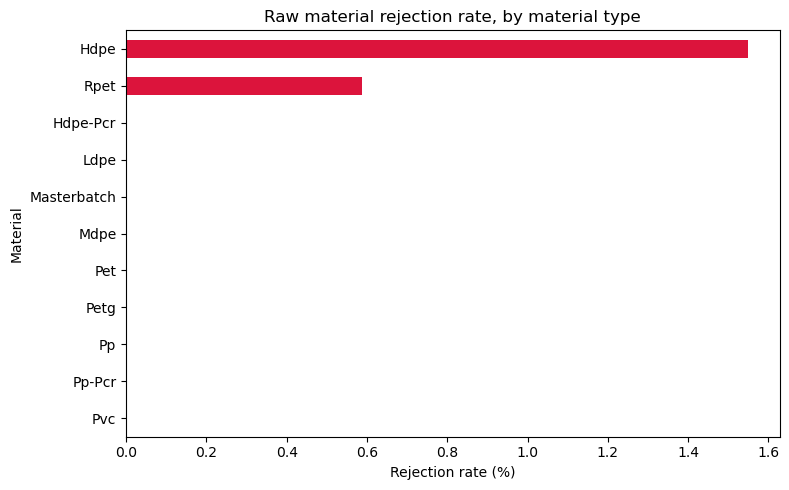

In [24]:
rejected = raw_material_disposition[raw_material_disposition["FinalDecision"] == "Rejected"]
rejection_rate = len(rejected) / len(raw_material_disposition)
print(f"Rejected lots: {len(rejected)} of {len(raw_material_disposition)} ({rejection_rate:.2%})")
print(f"Rejected quantity: {rejected['ReceivedQtyKg'].sum():,.0f} kg")

def pct_rejected(group):
    return (group == "Rejected").mean() * 100

rejection_by_material = (
    raw_material_disposition.groupby("Material")["FinalDecision"]
    .apply(pct_rejected)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
rejection_by_material.plot(kind="barh", color="crimson", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Rejection rate (%)")
ax.set_title("Raw material rejection rate, by material type")
plt.tight_layout()
plt.savefig(f"{REPORTS}/28_rejected_raw_material_by_type.png", dpi=150)
plt.show()


## Supplier approval rate

Percentage of a supplier's incoming lots that were accepted outright
(not counting accepted-with-deviation or rejected).


                            SupplierName  ApprovalRatePct
SupplierId                                               
SUP-007        Cerrado Petroquimica S.A.             93.4
SUP-002     Meridian Petrochemicals GmbH             94.0
SUP-004       TransAtlantic Polymers plc             94.2
SUP-006           Zenith Chemicals Group             94.3
SUP-001           PolyGlobal Resins Corp             95.4
SUP-008             Andes Polimeros S.A.             96.0
SUP-003      NorthStar Polymer Solutions             96.9
SUP-005        Orient Polymer Industries             97.6


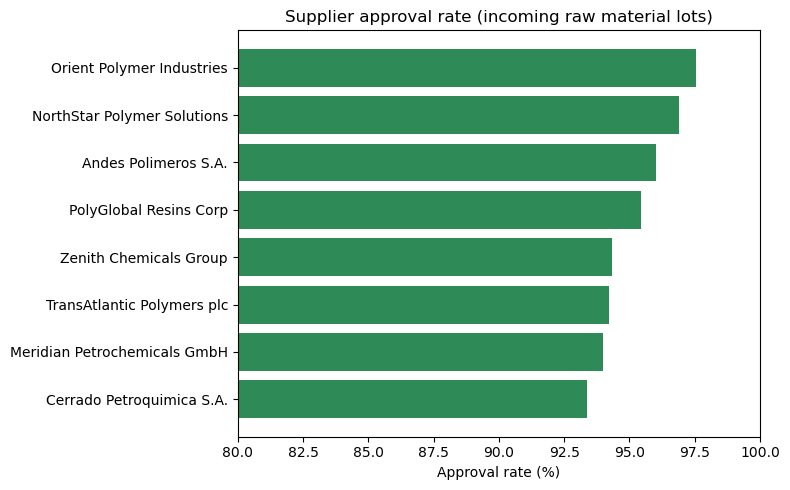

In [25]:
approval = etl.compute_supplier_approval_rate(raw_material_disposition)
approval = approval.join(dim_supplier.set_index("SupplierId")[["SupplierName"]])
approval = approval.sort_values("ApprovalRatePct")
print(approval[["SupplierName", "ApprovalRatePct"]].round(1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(approval["SupplierName"], approval["ApprovalRatePct"], color="seagreen")
ax.set_xlim(80, 100)
ax.set_xlabel("Approval rate (%)")
ax.set_title("Supplier approval rate (incoming raw material lots)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/29_supplier_approval_rate.png", dpi=150)
plt.show()


## Average supplier response time

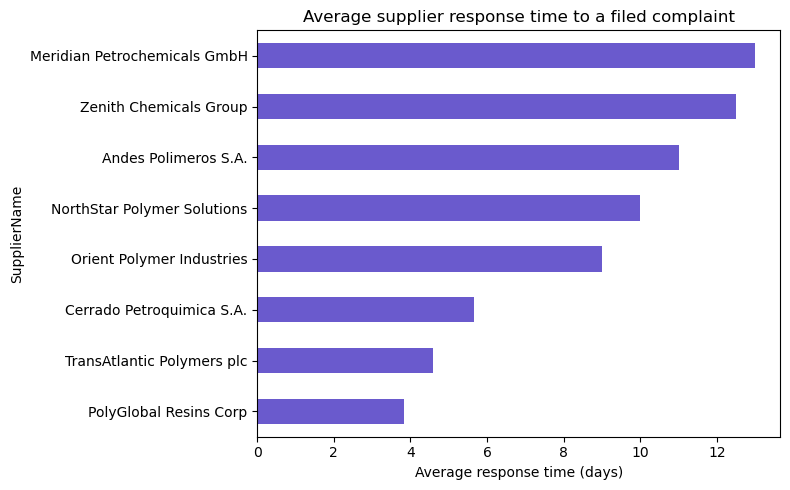

Plant-wide average response time: 7.0 days


In [26]:
response_time = (
    supplier_complaints.merge(dim_supplier[["SupplierId", "SupplierName"]], on="SupplierId")
    .groupby("SupplierName")["ResponseDays"].mean().sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
response_time.plot(kind="barh", color="slateblue", ax=ax)
ax.set_xlabel("Average response time (days)")
ax.set_title("Average supplier response time to a filed complaint")
plt.tight_layout()
plt.savefig(f"{REPORTS}/30_supplier_response_time.png", dpi=150)
plt.show()

print(f"Plant-wide average response time: {supplier_complaints['ResponseDays'].mean():.1f} days")


# Part 3 - Nonconformance and CAPA

## Internal vs. external NC

Type
External    304
Internal    208
Name: count, dtype: int64


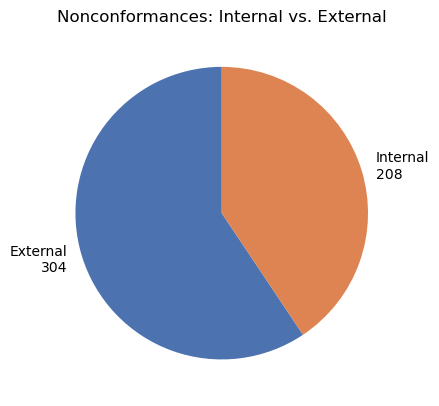

In [27]:
nc_type = nonconformance["Type"].value_counts()
print(nc_type)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.pie(nc_type.values, labels=[f"{i}\n{v}" for i, v in nc_type.items()],
       colors=["#4C72B0", "#DD8452"], startangle=90)
ax.set_title("Nonconformances: Internal vs. External")
plt.tight_layout()
plt.savefig(f"{REPORTS}/31_nc_internal_vs_external.png", dpi=150)
plt.show()


## NC by process and by area

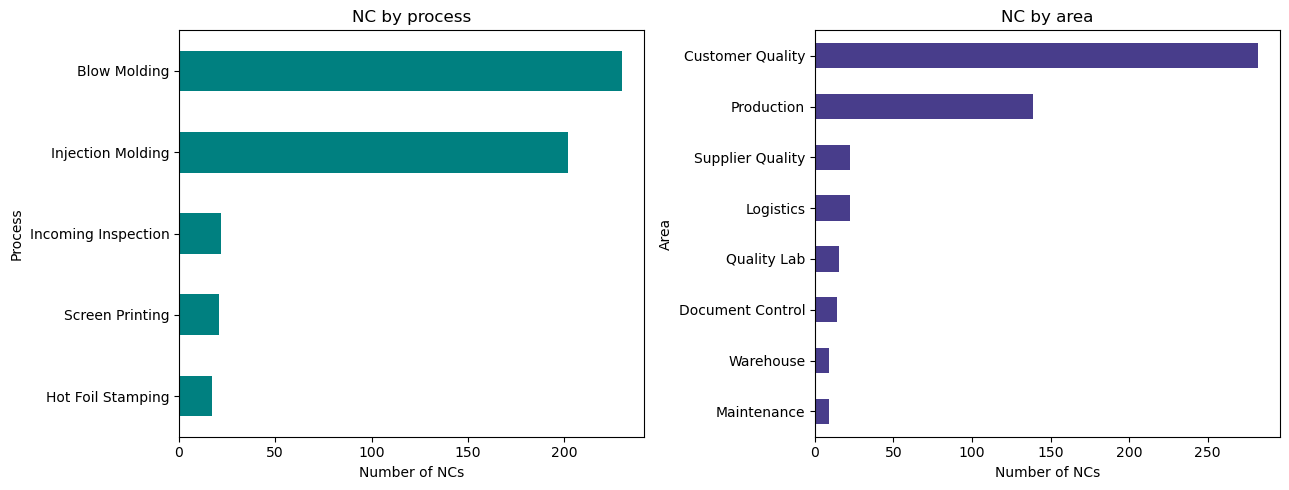

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nonconformance.groupby("Process").size().sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("NC by process")
axes[0].set_xlabel("Number of NCs")

nonconformance.groupby("Area").size().sort_values().plot(kind="barh", ax=axes[1], color="darkslateblue")
axes[1].set_title("NC by area")
axes[1].set_xlabel("Number of NCs")
plt.tight_layout()
plt.savefig(f"{REPORTS}/32_nc_by_process_and_area.png", dpi=150)
plt.show()


## CAPA: open, closed, overdue

Status
Closed     243
Overdue     93
Open        21
Name: count, dtype: int64


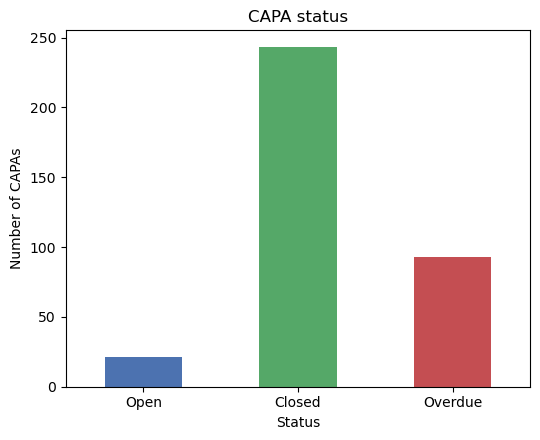

In [29]:
capa_status = capa["Status"].value_counts()
print(capa_status)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
capa_status.reindex(["Open", "Closed", "Overdue"]).plot(
    kind="bar", color=["#4C72B0", "#55A868", "#C44E52"], ax=ax
)
ax.set_ylabel("Number of CAPAs")
ax.set_title("CAPA status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{REPORTS}/33_capa_status.png", dpi=150)
plt.show()


## Average CAPA closure time

Average closure time: 46.8 days (n=243)


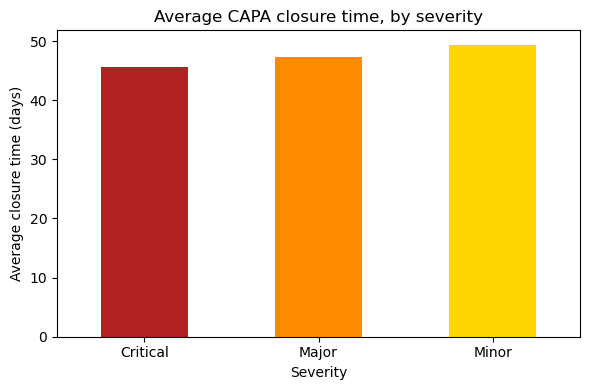

In [30]:
closed_capa = capa[capa["Status"] == "Closed"]
print(f"Average closure time: {closed_capa['ClosureDays'].mean():.1f} days (n={len(closed_capa)})")

closure_by_severity = closed_capa.groupby("Severity")["ClosureDays"].mean().reindex(["Critical", "Major", "Minor"])

fig, ax = plt.subplots(figsize=(6, 4))
closure_by_severity.plot(kind="bar", color=["firebrick", "darkorange", "gold"], ax=ax)
ax.set_ylabel("Average closure time (days)")
ax.set_title("Average CAPA closure time, by severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{REPORTS}/34_capa_closure_time_by_severity.png", dpi=150)
plt.show()


## Summary

- The plant-wide complaint rate is in the low single digits per
  million shipped -- a healthy benchmark for packaging components --
  but it varies noticeably by customer and by defect type.
- Supplier approval rate and response time point to which supplier
  relationships deserve more attention.
- Critical-severity CAPAs should close faster than Minor ones -- worth
  checking whether that's actually happening.
